# Example Notebook to run the GULF model

Note: the original model file from TWDB are mostly used As-Is, however file paths were converted from the windows '\' to a '/'

In [ ]:
from pathlib import Path
import flopy

bindir = Path("/tmp/bin")
bindir.mkdir(exist_ok=True)
flopy.utils.get_modflow(bindir)
list(bindir.iterdir())

# Or use an auto-select option
flopy.utils.get_modflow(":flopy")

In [3]:
# Load Libraries
import os
import sys
from pathlib import Path
from pprint import pformat
from shutil import copytree
from tempfile import TemporaryDirectory

import git
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pooch
import shapefile

import flopy

print(sys.version)
print(f"numpy version: {np.__version__}")
print(f"matplotlib version: {mpl.__version__}")
print(f"flopy version: {flopy.__version__}")

3.10.19 | packaged by conda-forge | (main, Oct 22 2025, 22:29:10) [GCC 14.3.0]
numpy version: 1.26.4
matplotlib version: 3.10.8
flopy version: 3.9.5


In [4]:
%matplotlib inline

In [1]:
# Set initial parameters
vmf6 = "mf6"
exe_name_mf6 = "mf6"
exe_mp = "mp6"

# Point to directory where the 
modeldir = '/corral-repl/tacc/aci/PT2050/projects/PTDATAX-272/twdb_gam_collection/Gulf_Coast_Aquifer_System_northern_portion_GAM_version_4.1/glfc_n_v4_tacc/gma14' 
sim_name = "mfsim.nam"

# This is the path to wherever you want to store the output of loading and running the model
modelpth  = 'model_output_directory' 

In [5]:
# load the model
sim = flopy.mf6.MFSimulation.load(
    sim_name=sim_name, version=vmf6, exe_name=exe_name_mf6, sim_ws=modeldir
)

loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    loading package ic...
    loading package oc...
    loading package npf...
    loading package drn...
    loading package riv...
    loading package ghb...
    loading package wel...
    loading package wel...
    loading package rch...
    loading package rch...
    loading package csub...
    loading package sto...
    loading package obs...
  loading solution package gma14...


In [7]:
# CHange working directory to modeldir - and copy inputs from existing model
newpth = os.path.join(modelpth)
sim.set_sim_path(newpth)

In [8]:
sim.write_simulation()
success, buff = sim.run_simulation()
if not success:
    print("Something bad happened.")


writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package gma14...
  writing model gma14...
    writing model name file...
    writing package dis...
    writing package ic...
    writing package oc...
    writing package npf...
    writing package drn_0...
    writing package riv_0...
    writing package ghb_0...
    writing package wel_0...
    writing package irr...
    writing package rch_oc...
    writing package rch_sc...
    writing package csub_obs...
    writing package csub...
    writing package sto...
    writing package obs...
FloPy is using the following executable to run the model: ../../../../../../../../home1/06562/lpearson/.local/share/flopy/bin/mf6
                                   MODFLOW 6
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                            VERSION 6.6.3 09/29/2025

   MODFLOW 6 compiled Oct 07 2025 22:51:46 with Intel(R) Fortran Intel(R) 64
   Compiler Classic fo

In [9]:
simname = 'gma14'
files = [f"{simname}.hds", f"{simname}.cbb"]
for f in files:
    if os.path.isfile(os.path.join(modelpth, f)):
        msg = "Output file located: {}".format(f)
        print(msg)
    else:
        errmsg = "Error. Output file cannot be found: {}".format(f)
        print(errmsg)

Output file located: gma14.hds
Output file located: gma14.cbb


## Visualize plots using examples from FloPY documentation

In [10]:
# get the modflow-6 model we want to plot
ml6 = sim.get_model(simname)

In [11]:
ml6.modelgrid.set_coord_info(angrot=-14)

In [12]:
fig = plt.figure(figsize=(15, 10))

<Figure size 1500x1000 with 0 Axes>

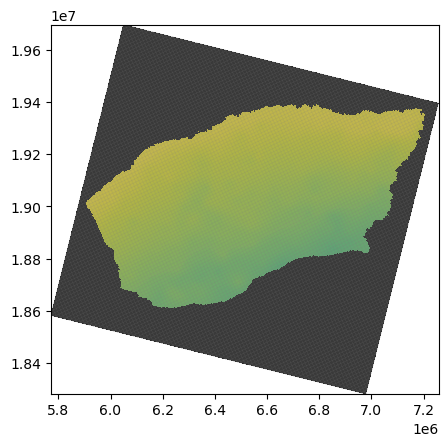

In [15]:
# plot boundary conditions
ax = fig.add_subplot(1, 2, 1, aspect="equal")
mapview = flopy.plot.PlotMapView(model=ml6)
quadmesh = mapview.plot_ibound()
quadmesh = mapview.plot_bc("RIV")
quadmesh = mapview.plot_bc("WEL")
linecollection = mapview.plot_grid(lw=.1)
ax.set_title("Plot boundary conditions")

# plot model bottom elevations
a = ml6.dis.botm.array

ax = fig.add_subplot(1, 2, 2, aspect="equal")
ax.set_title("Model Bottom Elevations")
mapview = flopy.plot.PlotMapView(model=ml6, layer=4)
quadmesh = mapview.plot_array(a)
inactive = mapview.plot_inactive()
linecollection = mapview.plot_grid(lw=.1)
cb = plt.colorbar(quadmesh, shrink=0.5, ax=ax)

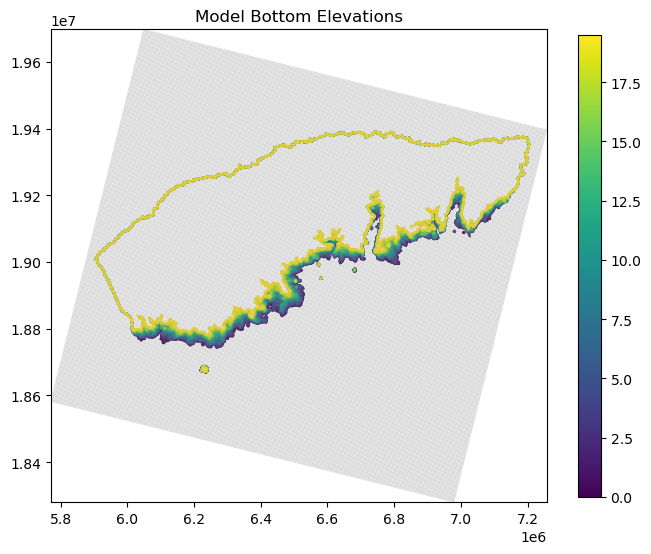

In [16]:
# The contour_array() method will take any keywords
# that can be used by the matplotlib.pyplot.contour
# function. So we can pass in levels, for example.
a = ml6.dis.botm.array
levels = np.arange(0, 20, 0.5)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(1, 1, 1, aspect="equal")
ax.set_title("Model Bottom Elevations")
mapview = flopy.plot.PlotMapView(model=ml6, layer=0)
contour_set = mapview.contour_array(a, levels=levels)
linecollection = mapview.plot_grid(lw=.1)

# set up and plot a continuous colorbar in matplotlib for a contour plot
norm = mpl.colors.Normalize(
    vmin=contour_set.cvalues.min(), vmax=contour_set.cvalues.max()
)
sm = plt.cm.ScalarMappable(norm=norm, cmap=contour_set.cmap)
sm.set_array([])
fig.colorbar(sm, shrink=0.75, ax=ax)

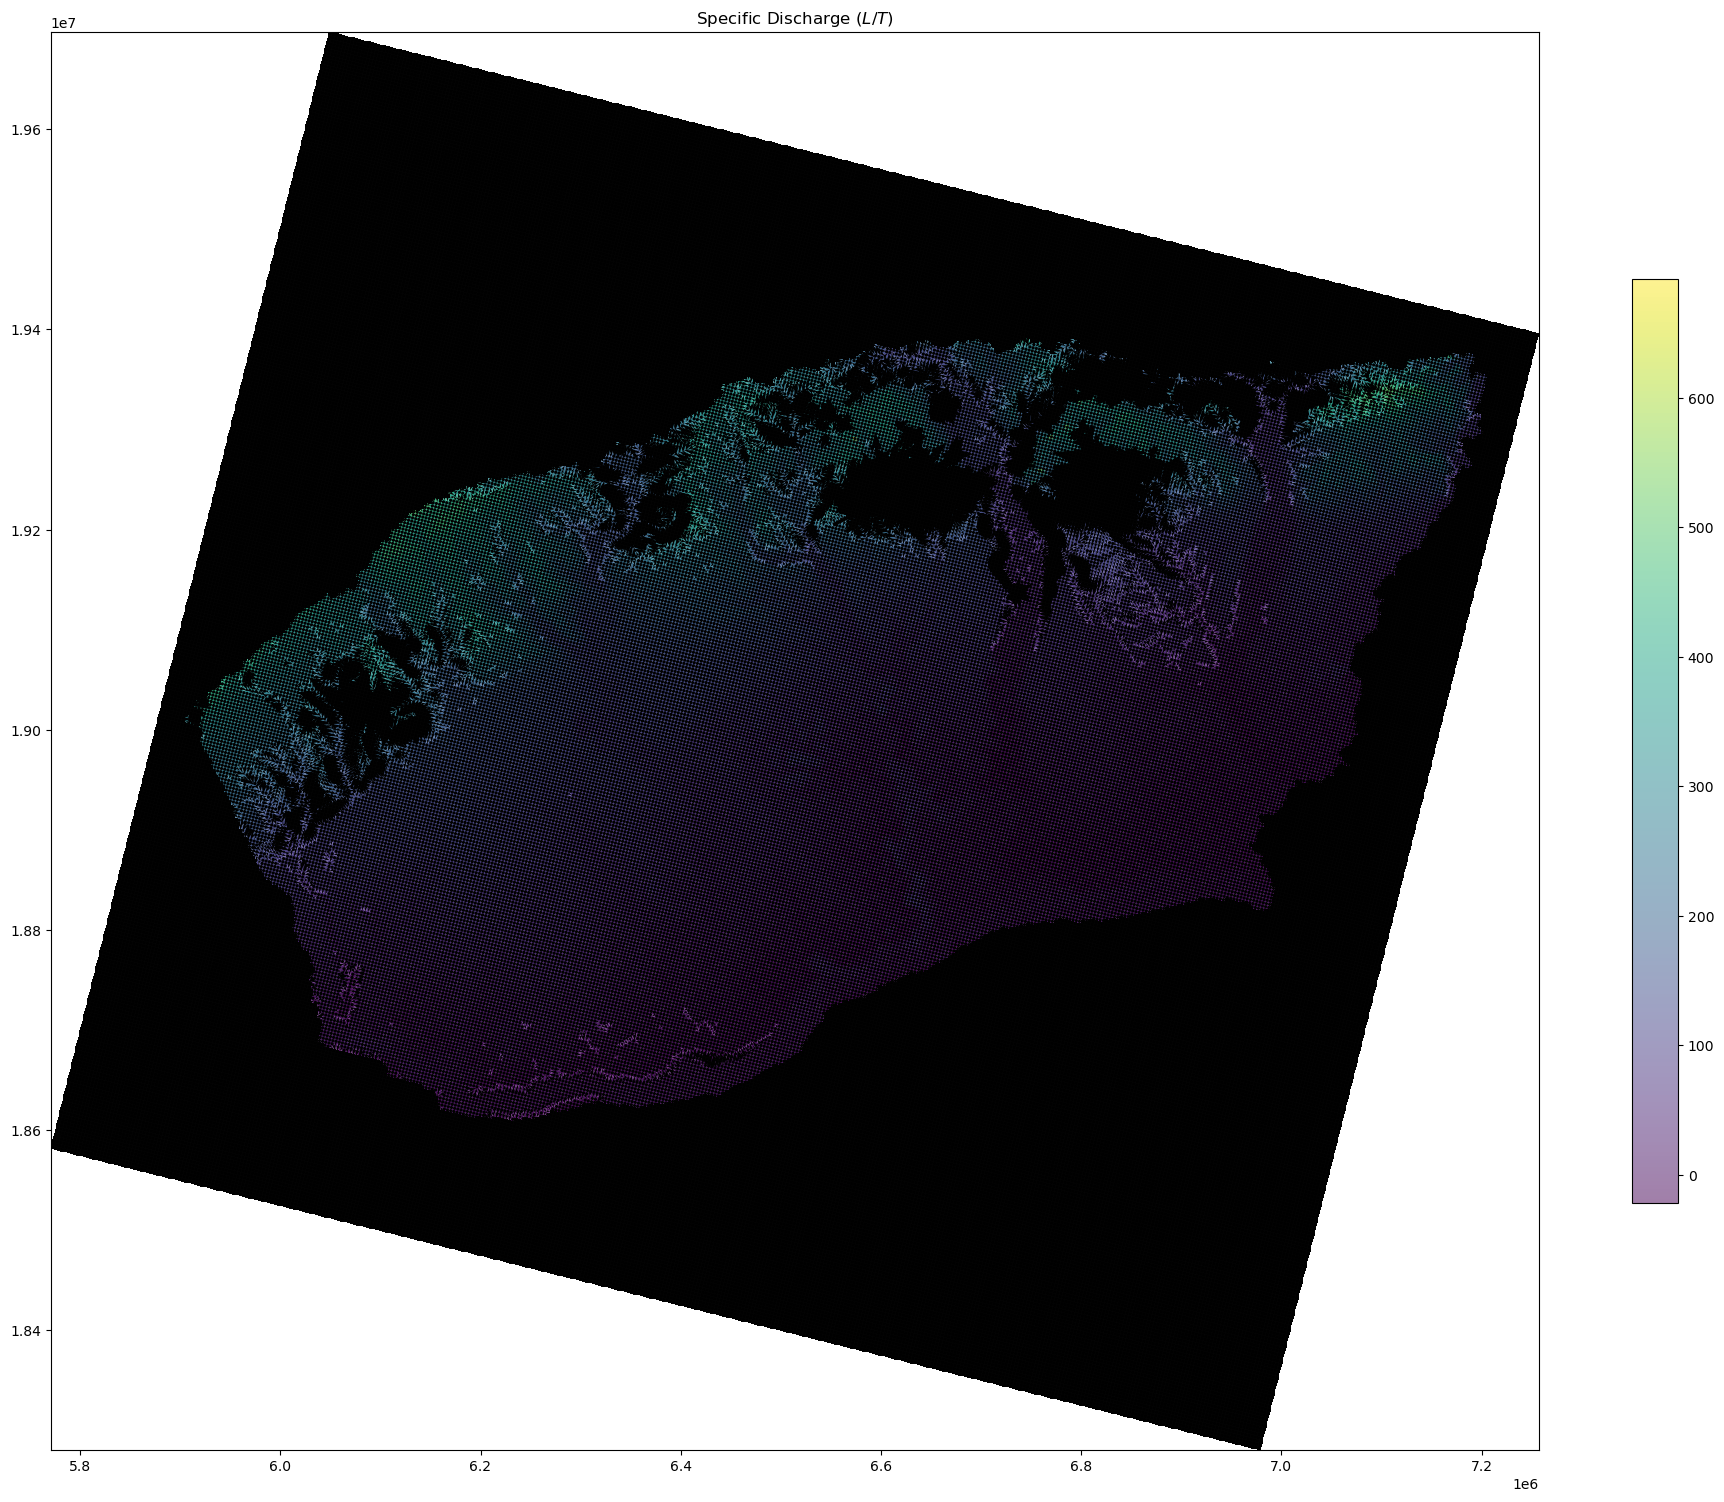

In [17]:
# get the specific discharge from the cell budget file
cbc_file = os.path.join(newpth, f"{simname}.cbb")
cbc = flopy.utils.CellBudgetFile(cbc_file)
spdis = cbc.get_data(text="SPDIS")[0]

qx, qy, qz = flopy.utils.postprocessing.get_specific_discharge(spdis, ml6)

# get the head from the head file
head_file = os.path.join(newpth, f"{simname}.hds")
head = flopy.utils.HeadFile(head_file)
hdata = head.get_alldata()[0]

# plot specific discharge using PlotMapView
fig = plt.figure(figsize=(24, 24))

mapview = flopy.plot.PlotMapView(model=ml6, layer=0)
linecollection = mapview.plot_grid(lw=.01)
quadmesh = mapview.plot_array(a=hdata, alpha=0.5)
quiver = mapview.plot_vector(qx, qy)
inactive = mapview.plot_inactive()

plt.title("Specific Discharge (" + r"$L/T$" + ")")
plt.colorbar(quadmesh, shrink=0.5)

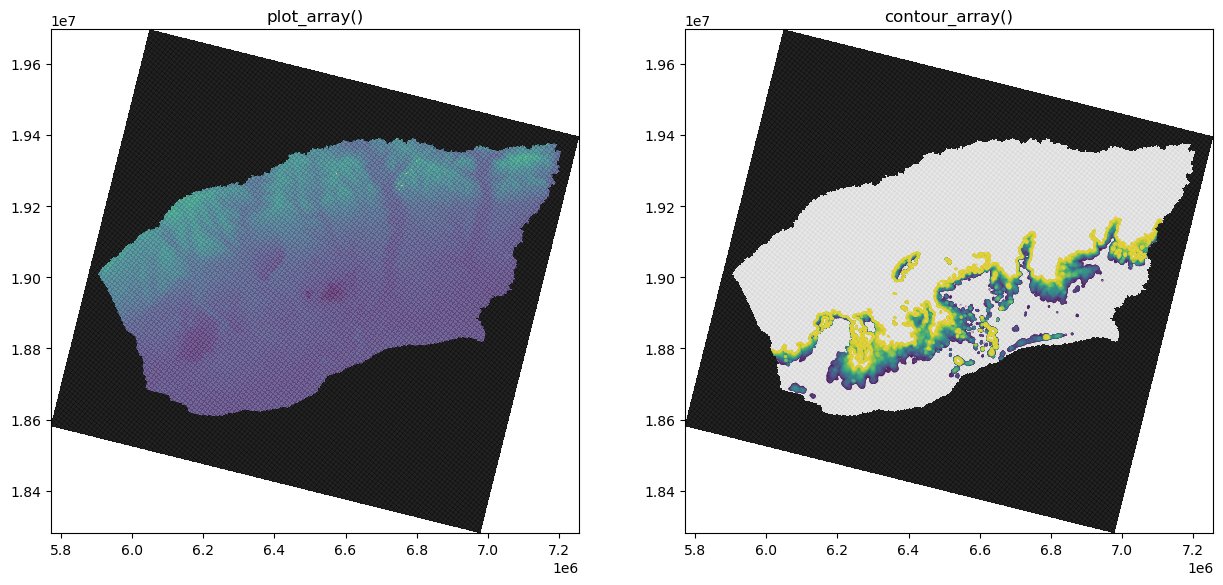

In [18]:
fname = os.path.join(modelpth, f"{simname}.hds")
hdobj = flopy.utils.HeadFile(fname)
head = hdobj.get_data()
levels = np.arange(10, 30, 0.5)

fig = plt.figure(figsize=(15, 10))

ax = fig.add_subplot(1, 2, 1, aspect="equal")
ax.set_title("plot_array()")
mapview = flopy.plot.PlotMapView(model=ml6)
quadmesh = mapview.plot_ibound()
quadmesh = mapview.plot_array(head, alpha=0.5)
mapview.plot_bc("WEL")
linecollection = mapview.plot_grid(lw=.1)

ax = fig.add_subplot(1, 2, 2, aspect="equal")
ax.set_title("contour_array()")
mapview = flopy.plot.PlotMapView(model=ml6)
quadmesh = mapview.plot_ibound()
mapview.plot_bc("WEL")
contour_set = mapview.contour_array(head, levels=levels)
linecollection = mapview.plot_grid(lw=.1)